# Import Prerequisites

In [1]:
#import statements

import numpy as np
import pandas as pd
from glob import glob
from datetime import date, timedelta
import datetime
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from tabulate import tabulate

warnings.filterwarnings("ignore")
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 9

# Dataset Processing

In [3]:
case_time = pd.read_csv('../districts.csv', parse_dates = True)
case_time

,Date,State,District,Confirmed,Recovered,Deceased,Other,Tested
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0,0,2679.0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4,0,NaN
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0,0,NaN
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0,0,NaN
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8,0,NaN
...,...,...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129,0,NaN
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326,0,NaN
258557,2021-06-02,West Bengal,Purulia,18613,17974,107,0,NaN
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111,0,NaN


In [4]:
case_time = case_time[["Date","State","District","Confirmed","Recovered","Deceased"]]
case_time

,Date,State,District,Confirmed,Recovered,Deceased
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8
...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326
258557,2021-06-02,West Bengal,Purulia,18613,17974,107
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111


In [5]:
state = 'Tamil Nadu'
state_data = case_time[case_time['State'] == state]
state_data

,Date,State,District,Confirmed,Recovered,Deceased
291,2020-04-26,Tamil Nadu,Ariyalur,5,2,0
292,2020-04-26,Tamil Nadu,Chengalpattu,55,40,2
293,2020-04-26,Tamil Nadu,Chennai,528,161,12
294,2020-04-26,Tamil Nadu,Coimbatore,141,94,0
295,2020-04-26,Tamil Nadu,Cuddalore,26,18,0
...,...,...,...,...,...,...
258435,2021-06-02,Tamil Nadu,Tiruppur,62296,43219,483
258436,2021-06-02,Tamil Nadu,Tiruvannamalai,41761,33951,424
258437,2021-06-02,Tamil Nadu,Vellore,42577,38827,751
258438,2021-06-02,Tamil Nadu,Viluppuram,35042,29672,253


In [6]:
district_list = state_data['District'].unique()

district_data = dict()
district_data_21 = dict()
for districts in district_list:
    district_data.update({districts:0})
for districts in district_list:
    district_data_21.update({districts:0})

In [7]:
#calander like dataframe

sdate = date(2020, 1, 1)
edate = date(2020, 12, 31)

delta = edate - sdate
dates = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates.append(day)

In [8]:
#calander like dataframe

sdate = date(2021, 1, 1)
edate = date(2021, 5, 30)

delta = edate - sdate
dates_21 = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates_21.append(day)

In [9]:
print("Preparing chronological district data for year 2020")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x
    print("=",end="")
            
            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data[district] = cal_dat
print(" ||")

Preparing chronological district data for year 2020
|| ========================================= ||


In [10]:
print("Preparing chronological district data for year 2021")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates_21
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x
    print("=",end="")
            
            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data_21[district] = cal_dat
print(" ||")

Preparing chronological district data for year 2021
|| ========================================= ||


Trend of Active cases in Coimbatore for the year 2020


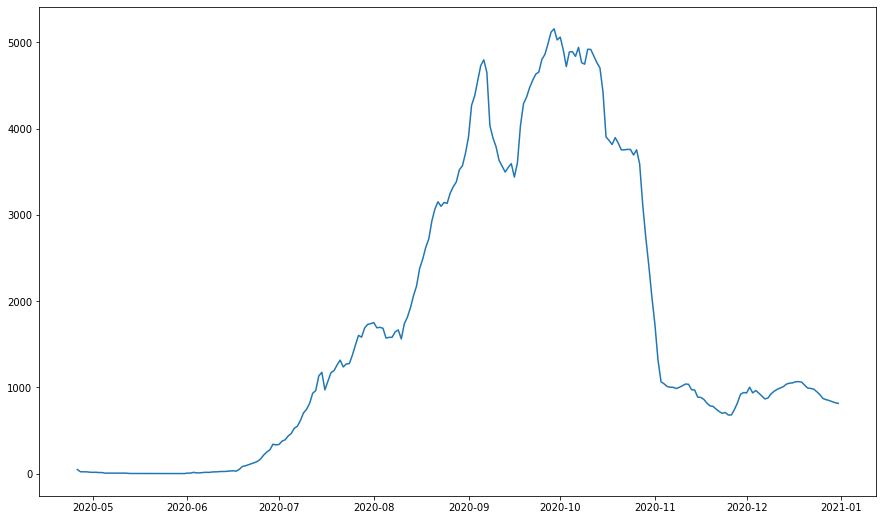

In [11]:
district = 'Coimbatore'
pd.set_option('display.max_rows',466)
bang_data = district_data[district][district_data[district]['Active'] != 'DNA']
bang_data = bang_data[["Active"]]
bang_data = bang_data.astype(int)
print("Trend of Active cases in",district,"for the year 2020")
plt.plot(bang_data)

Trend of COVID-19 cases in Coimbatore for the year 2021



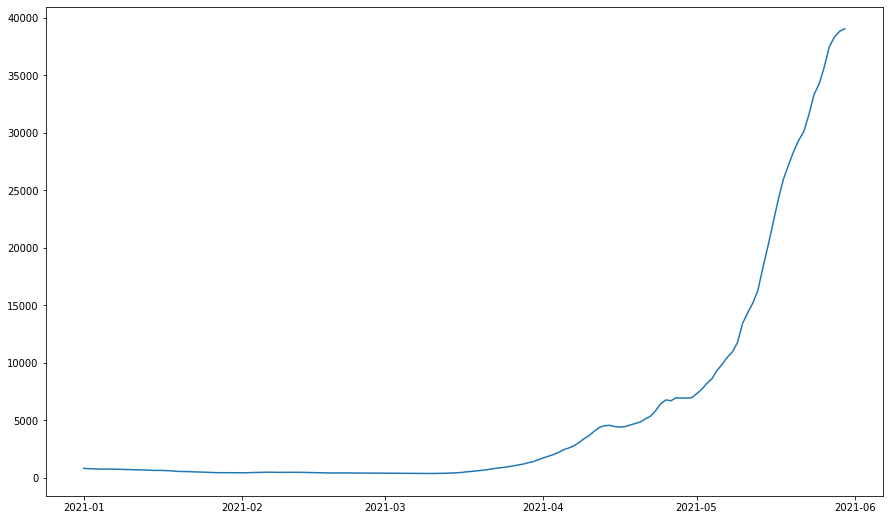

In [12]:
bang_data_21 = district_data_21[district][district_data_21[district]['Active'] != 'DNA']
bang_data_21 = bang_data_21[["Active"]]
bang_data_21 = bang_data_21.astype(int)
print("Trend of COVID-19 cases in",district,"for the year 2021\n")
plt.plot(bang_data_21)

In [13]:
quart_data = bang_data[bang_data.index >= datetime.date(2020, 1, 1)]
quart1_data = bang_data[quart_data.index < datetime.date(2020, 4, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 4, 1)]
quart2_data = bang_data[quart_data.index < datetime.date(2020, 7, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 7, 1)]
quart3_data = quart_data[quart_data.index < datetime.date(2020, 10, 1)]

quart4_data = bang_data[bang_data.index >= datetime.date(2020, 10, 1)]

COVID-19 cases in Coimbatore
            Active
Date              
2020-04-26      47
2020-04-27      21
2020-04-28      21
2020-04-29      20
2020-04-30      16
2020-05-01      14
2020-05-02      15
2020-05-03      12
2020-05-04      12
2020-05-05       5
2020-05-06       5
2020-05-07       5
2020-05-08       5
2020-05-09       5
2020-05-10       5
2020-05-11       5
2020-05-12       5
2020-05-13       1
2020-05-14       1
2020-05-15       1
2020-05-16       0
2020-05-17       0
2020-05-18       0
2020-05-19       0
2020-05-20       0
2020-05-21       0
2020-05-22       0
2020-05-23       0
2020-05-24       0
2020-05-25       0
2020-05-26       0
2020-05-27       0
2020-05-28       0
2020-05-29       0
2020-05-30       0
2020-05-31       0
2020-06-01       5
2020-06-02       5
2020-06-03      14
2020-06-04       8
2020-06-05       8
2020-06-06      12
2020-06-07      15
2020-06-08      13
2020-06-09      18
2020-06-10      19
2020-06-11      21
2020-06-12      24
2020-06-13      24
20

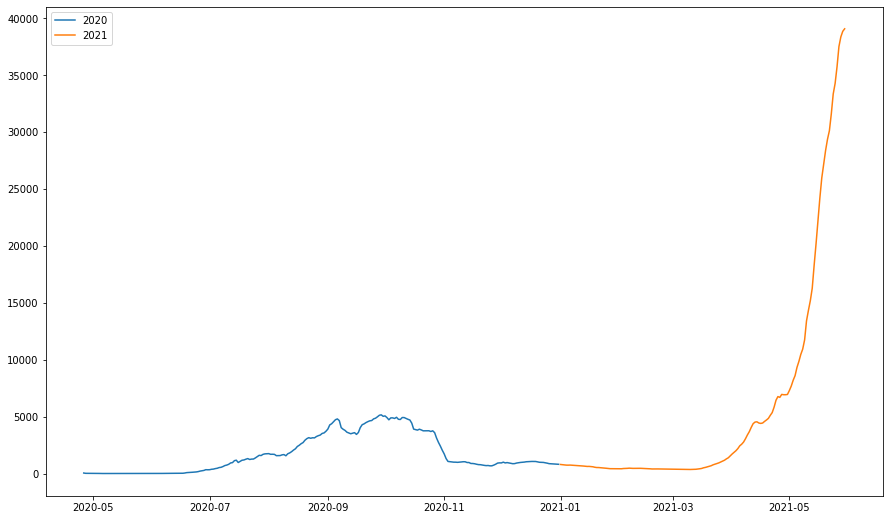

In [14]:
print("COVID-19 cases in",district)
print(bang_data)
print(bang_data_21)
plt.plot(bang_data)
plt.plot(bang_data_21)
plt.legend(['2020','2021'])

# RNN Implementation

In [15]:

# univariate lstm example
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten


In [16]:
# preparing independent and dependent features
def prepare_data(timeseries_data, n_features):
    X, y =[],[]
    for i in range(len(timeseries_data)):
        # find the end of this pattern
        end_ix = i + n_features
        # check if we are beyond the sequence
        if end_ix > len(timeseries_data)-1:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = timeseries_data[i:end_ix], timeseries_data[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [17]:
n_steps = 7  
n_features = 1
def prep_data(mod_data):
    # define input sequence
    timeseries_data = mod_data.values
    # choose a number of time steps
    # split into samples
    X, y = prepare_data(timeseries_data, n_steps)
    return X,y

In [18]:
def train_model(X,y):
    # reshape from [samples, timesteps] into [samples, timesteps, features]
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    
    # define model
    model = Sequential()
    model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(n_steps, n_features)))
    model.add(LSTM(50, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    # fit model
    model.fit(X, y, epochs=300, verbose=1)
    print(model.summary())
    
    return model


# Forecast over 1st test interval

In [19]:
# demonstrate prediction for next 10 days
def pred_nxt(days,dta):
    X, y = prep_data(dta)
    model = train_model(X,y)
    x_input = np.array(y[-8:])
    temp_input=list(x_input)
    lst_output=[]
    i=0
    while(i<days):

        if(len(temp_input)>3):
            x_input=np.array(temp_input[1:])
            print("{} day input {}".format(i,x_input))
            x_input = x_input.reshape((1, n_steps, n_features))
            yhat = model.predict(x_input, verbose=0)
            print("{} day output {}".format(i,yhat))
            temp_input.append(yhat[0][0])
            temp_input=temp_input[1:]
            #print(temp_input)
            lst_output.append(yhat[0][0])
            i=i+1
        else:
            print(x_input)
            x_input = x_input.reshape((1, n_steps, n_features))
            yhat = model.predict(x_input, verbose=0)
            print(yhat[0])
            temp_input.append(yhat[0][0])
            lst_output.append(yhat[0][0])
            i=i+1


    return (lst_output)

In [20]:
def get_err(ress):
    lst = bang_data_21.values
    sm = 0
    l = min(len(bang_data_21),len(ress))
    for i in range(l):
        x = ((lst[i]-ress[i])/lst[i])**2
        sm = sm + x
    rmse = 100 - (math.sqrt(sm/l))*100
    return rmse

In [21]:
rmse_for_tab = []
for i in range(1,15):
    period = int(i)
    ress = pred_nxt(i,bang_data)
    rmse = get_err(ress)
    rmse_for_tab.append(rmse)

Instructions for updating:
Colocations handled automatically by placer.
Instructions for updating:
Use tf.cast instead.
Instructions for updating:
Use tf.cast instead.
Epoch 1/300
243/243 [==============================] - 2s 9ms/sample - loss: 5198045.6368
Epoch 2/300
243/243 [==============================] - 0s 320us/sample - loss: 3899506.9918
Epoch 3/300
243/243 [==============================] - 0s 337us/sample - loss: 2607988.7230
Epoch 4/300
243/243 [==============================] - 0s 316us/sample - loss: 359244.7139
Epoch 5/300
243/243 [==============================] - 0s 296us/sample - loss: 220008.5294
Epoch 6/300
243/243 [==============================] - 0s 300us/sample - loss: 123719.0260
Epoch 7/300
243/243 [==============================] - 0s 394us/sample - loss: 541882.8432
Epoch 8/300
243/243 [==============================] - 0s 439us/sample - loss: 241206.0103
Epoch 9/300
243/243 [==============================] - 0s 525us/sample - loss: 316397.0613
Epoch 10/300

243/243 [==============================] - 0s 345us/sample - loss: 26934.5944
Epoch 81/300
243/243 [==============================] - 0s 386us/sample - loss: 28808.5983
Epoch 82/300
243/243 [==============================] - 0s 435us/sample - loss: 22864.4633
Epoch 83/300
243/243 [==============================] - 0s 357us/sample - loss: 22707.6651
Epoch 84/300
243/243 [==============================] - 0s 320us/sample - loss: 29813.7500
Epoch 85/300
243/243 [==============================] - 0s 304us/sample - loss: 29481.8512
Epoch 86/300
243/243 [==============================] - 0s 312us/sample - loss: 36705.3676
Epoch 87/300
243/243 [==============================] - 0s 300us/sample - loss: 25706.2299
Epoch 88/300
243/243 [==============================] - 0s 316us/sample - loss: 23060.2048
Epoch 89/300
243/243 [==============================] - 0s 279us/sample - loss: 22171.2277
Epoch 90/300
243/243 [==============================] - 0s 291us/sample - loss: 22577.7616
Epoch 91/300

243/243 [==============================] - 0s 870us/sample - loss: 19848.5964
Epoch 170/300
243/243 [==============================] - 0s 521us/sample - loss: 23123.8735
Epoch 171/300
243/243 [==============================] - 0s 443us/sample - loss: 24022.4637
Epoch 172/300
243/243 [==============================] - 0s 439us/sample - loss: 23567.3148
Epoch 173/300
243/243 [==============================] - 0s 456us/sample - loss: 21594.1544
Epoch 174/300
243/243 [==============================] - 0s 349us/sample - loss: 20410.1004
Epoch 175/300
243/243 [==============================] - 0s 382us/sample - loss: 21091.2853
Epoch 176/300
243/243 [==============================] - 0s 337us/sample - loss: 20978.4638
Epoch 177/300
243/243 [==============================] - 0s 763us/sample - loss: 20795.6919
Epoch 178/300
243/243 [==============================] - 0s 550us/sample - loss: 20238.6356
Epoch 179/300
243/243 [==============================] - 0s 382us/sample - loss: 23486.9119
Ep

243/243 [==============================] - 0s 259us/sample - loss: 29169.9687
Epoch 259/300
243/243 [==============================] - 0s 271us/sample - loss: 22892.8787
Epoch 260/300
243/243 [==============================] - 0s 267us/sample - loss: 16953.3678
Epoch 261/300
243/243 [==============================] - 0s 263us/sample - loss: 15425.0338
Epoch 262/300
243/243 [==============================] - 0s 312us/sample - loss: 35323.4457
Epoch 263/300
243/243 [==============================] - 0s 312us/sample - loss: 47218.2464
Epoch 264/300
243/243 [==============================] - 0s 267us/sample - loss: 33617.4468
Epoch 265/300
243/243 [==============================] - 0s 267us/sample - loss: 30152.5799
Epoch 266/300
243/243 [==============================] - 0s 263us/sample - loss: 36255.1303
Epoch 267/300
243/243 [==============================] - 0s 263us/sample - loss: 25861.4876
Epoch 268/300
243/243 [==============================] - 0s 267us/sample - loss: 16883.2438
Ep

243/243 [==============================] - 0s 291us/sample - loss: 96599.9785
Epoch 39/300
243/243 [==============================] - 0s 267us/sample - loss: 77219.0037
Epoch 40/300
243/243 [==============================] - 0s 271us/sample - loss: 62219.7235
Epoch 41/300
243/243 [==============================] - 0s 296us/sample - loss: 45405.8588
Epoch 42/300
243/243 [==============================] - 0s 287us/sample - loss: 42622.7208
Epoch 43/300
243/243 [==============================] - 0s 300us/sample - loss: 45793.9804
Epoch 44/300
243/243 [==============================] - 0s 349us/sample - loss: 40164.4679
Epoch 45/300
243/243 [==============================] - 0s 291us/sample - loss: 42885.8101
Epoch 46/300
243/243 [==============================] - 0s 291us/sample - loss: 44349.3192
Epoch 47/300
243/243 [==============================] - 0s 296us/sample - loss: 39232.1269
Epoch 48/300
243/243 [==============================] - 0s 291us/sample - loss: 66115.1879
Epoch 49/300

...

243/243 [==============================] - 0s 361us/sample - loss: 48103.0745
Epoch 209/300
243/243 [==============================] - 0s 373us/sample - loss: 40957.9422
Epoch 210/300
243/243 [==============================] - 0s 353us/sample - loss: 39627.3170
Epoch 211/300
243/243 [==============================] - 0s 353us/sample - loss: 36684.7033
Epoch 212/300
243/243 [==============================] - 0s 357us/sample - loss: 40526.1518
Epoch 213/300
243/243 [==============================] - 0s 357us/sample - loss: 43309.8600
Epoch 214/300
243/243 [==============================] - 0s 365us/sample - loss: 42021.5665
Epoch 215/300
243/243 [==============================] - 0s 369us/sample - loss: 35307.0958
Epoch 216/300
243/243 [==============================] - 0s 353us/sample - loss: 31286.3081
Epoch 217/300
243/243 [==============================] - 0s 378us/sample - loss: 50371.3322
Epoch 218/300
243/243 [==============================] - 0s 345us/sample - loss: 83647.9928
Ep

Epoch 297/300
243/243 [==============================] - 0s 365us/sample - loss: 22424.7563
Epoch 298/300
243/243 [==============================] - 0s 349us/sample - loss: 23217.2945
Epoch 299/300
243/243 [==============================] - 0s 361us/sample - loss: 21596.1929
Epoch 300/300
243/243 [==============================] - 0s 353us/sample - loss: 23044.8262
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_24 (LSTM)               (None, 7, 50)             10400     
_________________________________________________________________
lstm_25 (LSTM)               (None, 50)                20200     
_________________________________________________________________
dense_12 (Dense)             (None, 1)                 51        
Total params: 30,651
Trainable params: 30,651
Non-trainable params: 0
_________________________________________________________________
None
0 day input [[914]
 [870]
 [8

243/243 [==============================] - 0s 328us/sample - loss: 53579.0394
Epoch 63/300
243/243 [==============================] - 0s 308us/sample - loss: 67849.9943
Epoch 64/300
243/243 [==============================] - 0s 308us/sample - loss: 77306.4539
Epoch 65/300
243/243 [==============================] - 0s 324us/sample - loss: 91910.7573
Epoch 66/300
243/243 [==============================] - 0s 304us/sample - loss: 98114.7666
Epoch 67/300
243/243 [==============================] - 0s 300us/sample - loss: 96060.0795
Epoch 68/300
243/243 [==============================] - 0s 300us/sample - loss: 88719.9991
Epoch 69/300
243/243 [==============================] - 0s 304us/sample - loss: 83798.2741
Epoch 70/300
243/243 [==============================] - 0s 302us/sample - loss: 68209.6508
Epoch 71/300
243/243 [==============================] - 0s 299us/sample - loss: 73376.1563
Epoch 72/300
243/243 [==============================] - 0s 300us/sample - loss: 75780.6954
Epoch 73/300

243/243 [==============================] - 0s 357us/sample - loss: 50959.0945
Epoch 152/300
243/243 [==============================] - 0s 341us/sample - loss: 42463.6768
Epoch 153/300
243/243 [==============================] - 0s 341us/sample - loss: 43339.4307
Epoch 154/300
243/243 [==============================] - 0s 357us/sample - loss: 58148.7624
Epoch 155/300
243/243 [==============================] - 0s 337us/sample - loss: 56882.9543
Epoch 156/300
243/243 [==============================] - 0s 369us/sample - loss: 58600.7970
Epoch 157/300
243/243 [==============================] - 0s 353us/sample - loss: 56958.1891
Epoch 158/300
243/243 [==============================] - 0s 357us/sample - loss: 45460.0213
Epoch 159/300
243/243 [==============================] - 0s 337us/sample - loss: 42764.3971
Epoch 160/300
243/243 [==============================] - 0s 337us/sample - loss: 42336.9984
Epoch 161/300
243/243 [==============================] - 0s 349us/sample - loss: 42992.0728
Ep

243/243 [==============================] - 0s 369us/sample - loss: 25817.8218
Epoch 241/300
243/243 [==============================] - 0s 369us/sample - loss: 37206.2507
Epoch 242/300
243/243 [==============================] - 0s 332us/sample - loss: 40112.0649
Epoch 243/300
243/243 [==============================] - 0s 332us/sample - loss: 50217.8711
Epoch 244/300
243/243 [==============================] - 0s 337us/sample - loss: 29726.9232
Epoch 245/300
243/243 [==============================] - 0s 357us/sample - loss: 31736.2083
Epoch 246/300
243/243 [==============================] - 0s 349us/sample - loss: 33958.2869
Epoch 247/300
243/243 [==============================] - 0s 345us/sample - loss: 29677.7793
Epoch 248/300
243/243 [==============================] - 0s 345us/sample - loss: 32484.5228
Epoch 249/300
243/243 [==============================] - 0s 328us/sample - loss: 23836.1754
Epoch 250/300
243/243 [==============================] - 0s 382us/sample - loss: 23828.6107
Ep

In [22]:
ress = pred_nxt(10,bang_data)

Epoch 1/300
243/243 [==============================] - 4s 18ms/sample - loss: 3572887.4959
Epoch 2/300
243/243 [==============================] - 0s 390us/sample - loss: 1229007.6076
Epoch 3/300
243/243 [==============================] - 0s 390us/sample - loss: 224745.6376
Epoch 4/300
243/243 [==============================] - 0s 382us/sample - loss: 416915.0005
Epoch 5/300
243/243 [==============================] - 0s 365us/sample - loss: 829374.1227
Epoch 6/300
243/243 [==============================] - 0s 365us/sample - loss: 469662.2683
Epoch 7/300
243/243 [==============================] - 0s 468us/sample - loss: 326906.9879
Epoch 8/300
243/243 [==============================] - 0s 390us/sample - loss: 342332.5355
Epoch 9/300
243/243 [==============================] - 0s 443us/sample - loss: 464484.6119
Epoch 10/300
243/243 [==============================] - 0s 694us/sample - loss: 330474.2537
Epoch 11/300
243/243 [==============================] - 0s 423us/sample - loss: 421295.3

243/243 [==============================] - 0s 353us/sample - loss: 53867.3939
Epoch 91/300
243/243 [==============================] - 0s 357us/sample - loss: 50301.5421
Epoch 92/300
243/243 [==============================] - 0s 349us/sample - loss: 52094.2236
Epoch 93/300
243/243 [==============================] - 0s 341us/sample - loss: 61546.8079
Epoch 94/300
243/243 [==============================] - 0s 353us/sample - loss: 68819.1342
Epoch 95/300
243/243 [==============================] - 0s 357us/sample - loss: 48137.1317
Epoch 96/300
243/243 [==============================] - 0s 353us/sample - loss: 191466.6619
Epoch 97/300
243/243 [==============================] - 0s 369us/sample - loss: 258746.6475
Epoch 98/300
243/243 [==============================] - 0s 349us/sample - loss: 85273.9805
Epoch 99/300
243/243 [==============================] - 0s 353us/sample - loss: 79676.3456
Epoch 100/300
243/243 [==============================] - 0s 361us/sample - loss: 115778.6210
Epoch 10

243/243 [==============================] - 0s 386us/sample - loss: 45728.4901
Epoch 179/300
243/243 [==============================] - 0s 357us/sample - loss: 32998.7313
Epoch 180/300
243/243 [==============================] - 0s 357us/sample - loss: 44933.9290
Epoch 181/300
243/243 [==============================] - 0s 369us/sample - loss: 54964.7594
Epoch 182/300
243/243 [==============================] - 0s 349us/sample - loss: 54484.8900s - loss: 52446.031
Epoch 183/300
243/243 [==============================] - 0s 357us/sample - loss: 40929.4964
Epoch 184/300
243/243 [==============================] - 0s 345us/sample - loss: 68351.8358
Epoch 185/300
243/243 [==============================] - 0s 390us/sample - loss: 64743.1238
Epoch 186/300
243/243 [==============================] - 0s 349us/sample - loss: 78311.9758
Epoch 187/300
243/243 [==============================] - 0s 369us/sample - loss: 68736.7893
Epoch 188/300
243/243 [==============================] - 0s 361us/sample - 

243/243 [==============================] - 0s 361us/sample - loss: 28063.3616
Epoch 267/300
243/243 [==============================] - 0s 345us/sample - loss: 30208.8950
Epoch 268/300
243/243 [==============================] - 0s 345us/sample - loss: 29676.4179
Epoch 269/300
243/243 [==============================] - 0s 349us/sample - loss: 29699.7327
Epoch 270/300
243/243 [==============================] - 0s 337us/sample - loss: 29447.4192
Epoch 271/300
243/243 [==============================] - 0s 341us/sample - loss: 26539.1346
Epoch 272/300
243/243 [==============================] - 0s 341us/sample - loss: 36085.2844
Epoch 273/300
243/243 [==============================] - 0s 341us/sample - loss: 27424.7069
Epoch 274/300
243/243 [==============================] - 0s 341us/sample - loss: 27331.5072
Epoch 275/300
243/243 [==============================] - 0s 337us/sample - loss: 27723.5173
Epoch 276/300
243/243 [==============================] - 0s 337us/sample - loss: 26366.3490
Ep

Forecast of trend of growth of COVID-19 for the 1st test interval
              Forecast  Daily forecast  Confidence interval  Actual  Daily
Date                                                                      
2021-01-01  796.765198             -18            96.652183     798    -16
2021-01-02  785.442566             -11            96.576723     779    -19
2021-01-03  773.734314             -12            97.050594     753    -26
2021-01-04  761.838318             -12            89.607773     742    -11
2021-01-05  750.215576             -11            93.586380     738     -4
2021-01-06  738.965576             -12            89.590449     745      7
2021-01-07  727.507690             -11            91.641312     734    -11
2021-01-08  716.584473             -11            94.017784     731     -3
2021-01-09  705.730896             -11            94.282361     712    -19
2021-01-10  695.048584             -10            85.906924     704     -8


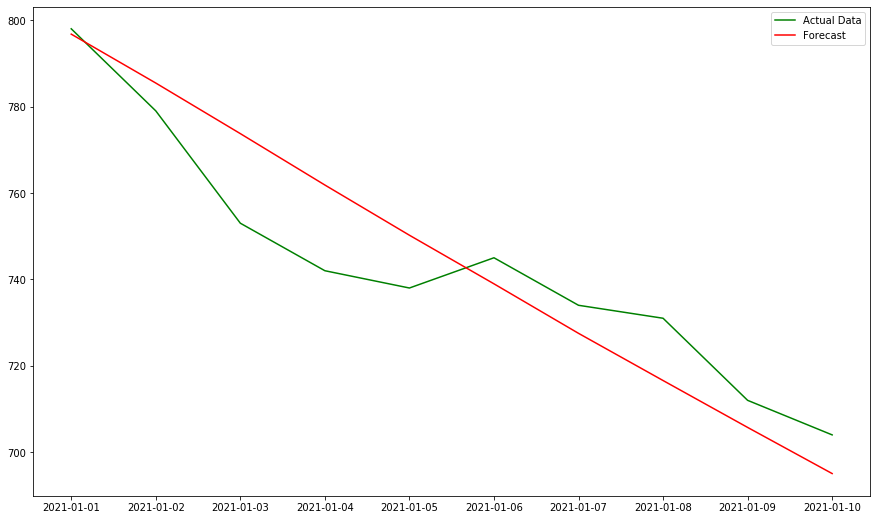

In [23]:
dt = bang_data.index[-1]
end = dt + datetime.timedelta(days=len(ress)+1)
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step

tst = pd.DataFrame()
tst['Date'] = dtframe[1:]
tst['Forecast'] = ress

print("Forecast of trend of growth of COVID-19 for the 1st test interval")
daily = []
daily.append(int(ress[0])-int(bang_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(ress[i])-int(ress[i-1]))
tst['Daily forecast'] = daily
tst['Confidence interval'] = rmse_for_tab[:len(ress)]
tst['Actual'] = bang_data_21.values[:len(ress)]
cum = bang_data_21.values
daily = []
daily.append(int(cum[0])-int(bang_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(cum[i])-int(cum[i-1]))
tst['Daily'] = daily
tst.set_index('Date',inplace=True)

print(tst)
plt.plot(tst['Actual'],color='green')
plt.plot(tst['Forecast'],color='red')
plt.legend(['Actual Data','Forecast'])

In [24]:
all_data = pd.concat([bang_data,bang_data_21])

In [25]:
dayss = 9
trdata = all_data[:-dayss]
tsdata = all_data[-dayss:]
ress = pred_nxt(dayss,trdata)

dt = trdata.index[-1]
end = dt + datetime.timedelta(days=dayss)
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step
    
cum = ress
dates = dtframe
daily = []
daily.append(cum[0]-bang_data[-1:].values)
data = []
for i in range(1,len(cum)):
    dd = []
    daily.append(cum[i]-cum[i-1])
    dts = tsdata.values[i] - tsdata.values[i-1]
    dd = [dates[i],int(daily[i]),int(cum[i]),rmse_for_tab[i],dts,tsdata.values[i]]
    data.append(dd)


Epoch 1/300
384/384 [==============================] - 5s 12ms/sample - loss: 20313871.0417
Epoch 2/300
384/384 [==============================] - 0s 327us/sample - loss: 13767847.7083
Epoch 3/300
384/384 [==============================] - 0s 358us/sample - loss: 3121998.4049
Epoch 4/300
384/384 [==============================] - 0s 348us/sample - loss: 1107815.7969
Epoch 5/300
384/384 [==============================] - 0s 335us/sample - loss: 836517.5397
Epoch 6/300
384/384 [==============================] - 0s 335us/sample - loss: 407482.0840
Epoch 7/300
384/384 [==============================] - 0s 371us/sample - loss: 570655.5664
Epoch 8/300
384/384 [==============================] - 0s 340us/sample - loss: 483681.4395
Epoch 9/300
384/384 [==============================] - 0s 322us/sample - loss: 1021403.8281
Epoch 10/300
384/384 [==============================] - 0s 340us/sample - loss: 1996075.4583
Epoch 11/300
384/384 [==============================] - 0s 364us/sample - loss: 53

384/384 [==============================] - 0s 423us/sample - loss: 97008.2974
Epoch 91/300
384/384 [==============================] - 0s 397us/sample - loss: 71929.1880
Epoch 92/300
384/384 [==============================] - 0s 364us/sample - loss: 73305.3042
Epoch 93/300
384/384 [==============================] - 0s 327us/sample - loss: 68811.1999
Epoch 94/300
384/384 [==============================] - 0s 335us/sample - loss: 94060.7323
Epoch 95/300
384/384 [==============================] - 0s 330us/sample - loss: 93863.6859
Epoch 96/300
384/384 [==============================] - 0s 330us/sample - loss: 166361.8420
Epoch 97/300
384/384 [==============================] - 0s 330us/sample - loss: 100822.5021
Epoch 98/300
384/384 [==============================] - 0s 325us/sample - loss: 87198.5680
Epoch 99/300
384/384 [==============================] - 0s 322us/sample - loss: 82370.1706
Epoch 100/300
384/384 [==============================] - 0s 325us/sample - loss: 115691.7923
Epoch 10

384/384 [==============================] - 0s 330us/sample - loss: 70113.6992
Epoch 180/300
384/384 [==============================] - 0s 306us/sample - loss: 87874.8302
Epoch 181/300
384/384 [==============================] - 0s 304us/sample - loss: 74195.0143
Epoch 182/300
384/384 [==============================] - 0s 314us/sample - loss: 87100.8979
Epoch 183/300
384/384 [==============================] - 0s 327us/sample - loss: 79782.7558
Epoch 184/300
384/384 [==============================] - 0s 322us/sample - loss: 86038.6019
Epoch 185/300
384/384 [==============================] - 0s 319us/sample - loss: 77380.3979
Epoch 186/300
384/384 [==============================] - 0s 330us/sample - loss: 70799.5104
Epoch 187/300
384/384 [==============================] - 0s 325us/sample - loss: 69914.9058
Epoch 188/300
384/384 [==============================] - 0s 330us/sample - loss: 65469.3371
Epoch 189/300
384/384 [==============================] - 0s 322us/sample - loss: 69103.3428
Ep

384/384 [==============================] - 0s 338us/sample - loss: 98249.0229
Epoch 269/300
384/384 [==============================] - 0s 338us/sample - loss: 77639.0814
Epoch 270/300
384/384 [==============================] - 0s 343us/sample - loss: 60006.7355
Epoch 271/300
384/384 [==============================] - 0s 364us/sample - loss: 55268.2324
Epoch 272/300
384/384 [==============================] - 0s 384us/sample - loss: 58792.8867
Epoch 273/300
384/384 [==============================] - 0s 390us/sample - loss: 53868.5745
Epoch 274/300
384/384 [==============================] - 0s 369us/sample - loss: 58394.2925
Epoch 275/300
384/384 [==============================] - 0s 335us/sample - loss: 67056.6470
Epoch 276/300
384/384 [==============================] - 0s 366us/sample - loss: 55405.7070
Epoch 277/300
384/384 [==============================] - 0s 364us/sample - loss: 57940.9849
Epoch 278/300
384/384 [==============================] - 0s 408us/sample - loss: 59355.7739
Ep

Forecast of trend of growth of COVID-19 for the 2nd test interval
Date          Daily    Cumulative    Confidence Interval    Daily    Cumulative
----------  -------  ------------  ---------------------  -------  ------------
2021-05-22     1338         32918                96.5767     1474         31578
2021-05-23     1835         34754                97.0506     1747         33325
2021-05-24     1632         36386                89.6078      928         34253
2021-05-25     1976         38362                93.5864     1454         35707
2021-05-26     2008         40371                89.5904     1781         37488
2021-05-27     2136         42507                91.6413      848         38336
2021-05-28     2164         44671                94.0178      488         38824
2021-05-29     2368         47040                94.2824      223         39047


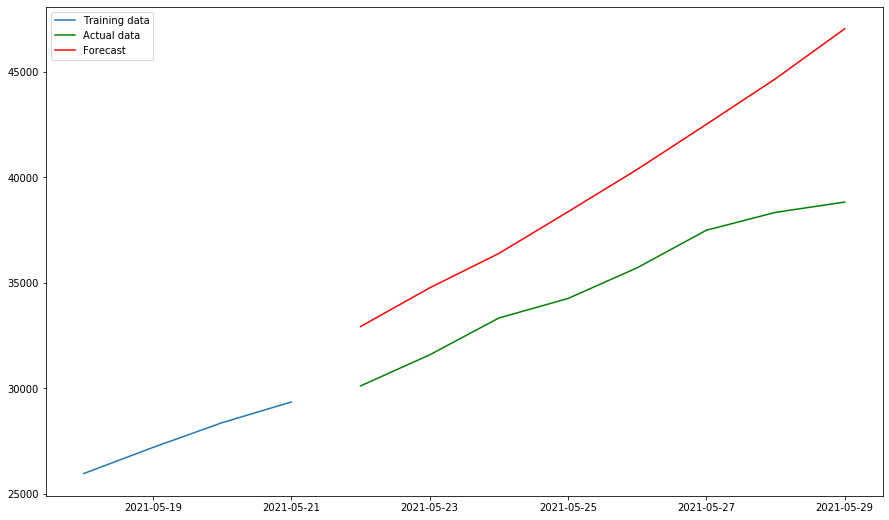

In [26]:
print("Forecast of trend of growth of COVID-19 for the 2nd test interval")
print(tabulate(data,headers=['Date','Daily','Cumulative','Confidence Interval','Daily','Cumulative']))
cum = [sub[2] for sub in data]
dts = [sub[0] for sub in data]
plt.plot(trdata[-int(dayss/2):])
plt.plot(tsdata[:len(cum)],color='green')
plt.plot(dts,cum,color = 'red')
plt.legend(['Training data','Actual data','Forecast'])

# Future forecast

In [27]:
all_data = pd.concat([bang_data,bang_data_21])
ress = pred_nxt(8,all_data)

Epoch 1/300
393/393 [==============================] - 5s 12ms/sample - loss: 49753659.4402
Epoch 2/300
393/393 [==============================] - ETA: 0s - loss: 40059525.66 - 0s 609us/sample - loss: 36279119.9437
Epoch 3/300
393/393 [==============================] - 0s 551us/sample - loss: 16398729.3028
Epoch 4/300
393/393 [==============================] - 0s 358us/sample - loss: 3471667.2820
Epoch 5/300
393/393 [==============================] - 0s 368us/sample - loss: 993398.4378
Epoch 6/300
393/393 [==============================] - 0s 462us/sample - loss: 624853.7919
Epoch 7/300
393/393 [==============================] - 0s 634us/sample - loss: 651698.6255
Epoch 8/300
393/393 [==============================] - 0s 594us/sample - loss: 1211361.6252
Epoch 9/300
393/393 [==============================] - 0s 510us/sample - loss: 617520.1675
Epoch 10/300
393/393 [==============================] - 0s 485us/sample - loss: 701157.4436
Epoch 11/300
393/393 [==============================

393/393 [==============================] - 0s 350us/sample - loss: 235182.6777
Epoch 90/300
393/393 [==============================] - 0s 343us/sample - loss: 262387.3082
Epoch 91/300
393/393 [==============================] - 0s 353us/sample - loss: 355334.0410
Epoch 92/300
393/393 [==============================] - 0s 332us/sample - loss: 202951.1444
Epoch 93/300
393/393 [==============================] - 0s 305us/sample - loss: 172761.8115
Epoch 94/300
393/393 [==============================] - 0s 310us/sample - loss: 251070.9587
Epoch 95/300
393/393 [==============================] - 0s 348us/sample - loss: 267665.7247
Epoch 96/300
393/393 [==============================] - 0s 360us/sample - loss: 696308.9273
Epoch 97/300
393/393 [==============================] - 0s 338us/sample - loss: 370089.5409
Epoch 98/300
393/393 [==============================] - 0s 338us/sample - loss: 219403.2080
Epoch 99/300
393/393 [==============================] - 0s 312us/sample - loss: 173843.4782
E

393/393 [==============================] - 0s 310us/sample - loss: 410804.5784
Epoch 178/300
393/393 [==============================] - 0s 310us/sample - loss: 128786.8596
Epoch 179/300
393/393 [==============================] - 0s 381us/sample - loss: 118407.8713
Epoch 180/300
393/393 [==============================] - 0s 492us/sample - loss: 115130.9717
Epoch 181/300
393/393 [==============================] - 0s 462us/sample - loss: 142526.1721
Epoch 182/300
393/393 [==============================] - 0s 396us/sample - loss: 231491.0099
Epoch 183/300
393/393 [==============================] - 0s 431us/sample - loss: 169655.2487
Epoch 184/300
393/393 [==============================] - 0s 419us/sample - loss: 94383.8543
Epoch 185/300
393/393 [==============================] - 0s 487us/sample - loss: 190844.6638
Epoch 186/300
393/393 [==============================] - 0s 472us/sample - loss: 178274.4534
Epoch 187/300
393/393 [==============================] - 0s 416us/sample - loss: 1938

393/393 [==============================] - 0s 325us/sample - loss: 101425.9849
Epoch 266/300
393/393 [==============================] - 0s 335us/sample - loss: 156142.4361
Epoch 267/300
393/393 [==============================] - 0s 322us/sample - loss: 280575.6450
Epoch 268/300
393/393 [==============================] - 0s 330us/sample - loss: 175792.7006
Epoch 269/300
393/393 [==============================] - 0s 325us/sample - loss: 129081.2036
Epoch 270/300
393/393 [==============================] - 0s 325us/sample - loss: 118228.2239
Epoch 271/300
393/393 [==============================] - 0s 327us/sample - loss: 102986.4451
Epoch 272/300
393/393 [==============================] - 0s 350us/sample - loss: 130553.3144
Epoch 273/300
393/393 [==============================] - 0s 338us/sample - loss: 99059.3405
Epoch 274/300
393/393 [==============================] - 0s 340us/sample - loss: 138045.7155
Epoch 275/300
393/393 [==============================] - 0s 332us/sample - loss: 8387

Future forecast of COVID-19
                Forecast  Daily forecast  Confidence interval
Date                                                         
2021-05-30  40435.917969            1388            96.652183
2021-05-31  40623.382812             188            96.576723
2021-06-01  40973.132812             350            97.050594
2021-06-02  41610.273438             637            89.607773
2021-06-03  41845.878906             235            93.586380
2021-06-04  42141.558594             296            89.590449
2021-06-05  42493.218750             352            91.641312
2021-06-06  42638.167969             145            94.017784


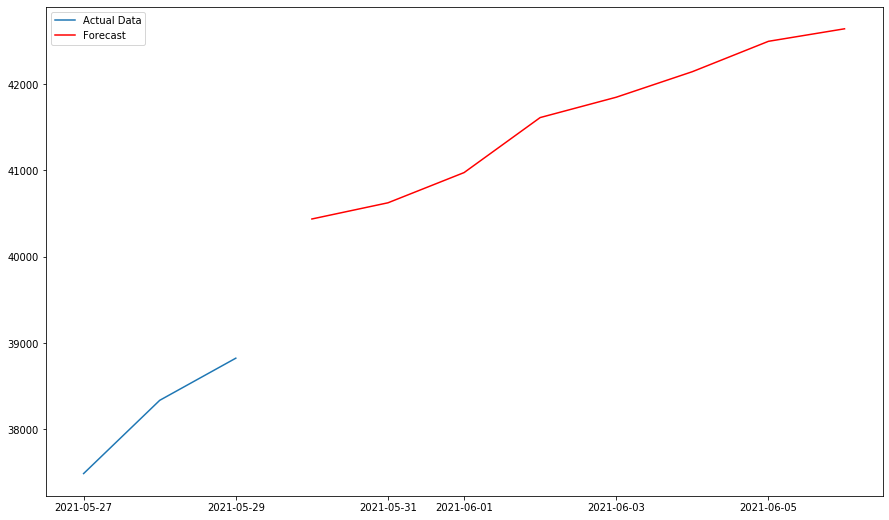

In [28]:
dt = all_data.index[-2]
end = dt + datetime.timedelta(days=len(ress)+1)
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step

print("Future forecast of COVID-19")
tst = pd.DataFrame()
tst['Date'] = dtframe[1:]
tst['Forecast'] = ress

daily = []
daily.append(int(ress[0])-int(all_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(ress[i])-int(ress[i-1]))
tst['Daily forecast'] = daily
tst['Confidence interval'] = rmse_for_tab[:len(ress)]
tst.set_index('Date',inplace=True)

print(tst)
plt.plot(all_data[-int(len(ress)/2):-1])
plt.plot(tst['Forecast'],color='red')
plt.legend(['Actual Data','Forecast'])